<a href="https://colab.research.google.com/github/Romfff/ThucHanhDeepLearning/blob/main/Tuan1_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. Cài đặt thư viện hỗ trợ đọc file Excel nếu cần
!pip install -q openpyxl

# 2. Import các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Đường dẫn tải file trực tiếp (Raw link) từ GitHub của bạn
url = "https://github.com/Romfff/ThucHanhDeepLearning/raw/main/Data/heart_disease_dataset.xlsx"

# 4. Đọc dữ liệu vào DataFrame
try:
    df = pd.read_excel(url)
    print("🎉 Tải và đọc dữ liệu thành công!")
except Exception as e:
    print(f"❌ Có lỗi xảy ra khi tải dữ liệu: {e}")

🎉 Tải và đọc dữ liệu thành công!


In [2]:
# Xem 5 dòng đầu tiên của tập dữ liệu
print("--- 5 DÒNG ĐẦU TIÊN ---")
display(df.head())

# Xem thông tin cấu trúc: kiểu dữ liệu, số lượng dòng/cột, dữ liệu bị khuyết (Missing values)
print("\n--- THÔNG TIN TẬP DỮ LIỆU ---")
df.info()

# Thống kê mô tả (Mean, Min, Max,...) của các biến số
print("\n--- THỐNG KÊ MÔ TẢ ---")
display(df.describe())

--- 5 DÒNG ĐẦU TIÊN ---


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,state
0,63.0,M,tap,145.0,233.0,yes,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0.0
1,67.0,M,asp,160.0,286.0,no,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2.0
2,67.0,M,asp,120.0,229.0,no,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1.0
3,37.0,M,nap,130.0,250.0,no,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0.0
4,41.0,F,aap,130.0,204.0,no,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0.0



--- THÔNG TIN TẬP DỮ LIỆU ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       295 non-null    float64
 1   sex       295 non-null    object 
 2   cp        292 non-null    object 
 3   trestbps  295 non-null    float64
 4   chol      293 non-null    float64
 5   fbs       295 non-null    object 
 6   restecg   295 non-null    float64
 7   thalach   291 non-null    float64
 8   exang     295 non-null    float64
 9   oldpeak   295 non-null    float64
 10  slope     295 non-null    float64
 11  ca        291 non-null    float64
 12  thal      295 non-null    float64
 13  state     293 non-null    float64
dtypes: float64(11), object(3)
memory usage: 33.3+ KB

--- THỐNG KÊ MÔ TẢ ---


,age,trestbps,chol,restecg,thalach,exang,oldpeak,slope,ca,thal,state
count,295.000000,295.000000,293.000000,295.000000,291.000000,295.000000,295.000000,295.000000,291.000000,295.000000,293.000000
mean,54.362712,131.389831,247.225256,1.003390,150.054983,0.318644,1.038644,1.589831,0.656357,4.671186,0.928328
std,9.040007,17.271361,51.819006,0.994879,22.684882,0.466742,1.170266,0.615474,0.931509,1.968377,1.229621
min,29.000000,94.000000,126.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,47.500000,120.000000,211.000000,0.000000,136.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,55.000000,130.000000,242.000000,1.000000,153.000000,0.000000,0.700000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,140.000000,276.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,200.000000,564.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


In [3]:
# 1. Kiểm tra xem có dòng nào bị trùng lặp không và xóa nếu có
duplicate_count = df.duplicated().sum()
print(f"Số dòng bị trùng lặp: {duplicate_count}")
if duplicate_count > 0:
    df = df.drop_duplicates()
    print("-> Đã xóa các dòng trùng lặp.")

# 2. Kiểm tra xem có ô nào bị bỏ trống (NaN) không
missing_values = df.isnull().sum()
print("\nSố lượng giá trị thiếu ở mỗi cột:")
print(missing_values[missing_values > 0]) # Chỉ in ra các cột bị thiếu dữ liệu

# Gợi ý xử lý nếu có dữ liệu thiếu (điền bằng giá trị trung vị - Median)
# df = df.fillna(df.median())

Số dòng bị trùng lặp: 7
-> Đã xóa các dòng trùng lặp.

Số lượng giá trị thiếu ở mỗi cột:
age         1
sex         1
cp          4
trestbps    1
chol        3
fbs         1
restecg     1
thalach     5
exang       1
oldpeak     1
slope       1
ca          5
thal        1
state       3
dtype: int64


/tmp/ipykernel_504/1682190334.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=target_col, palette="Set2")


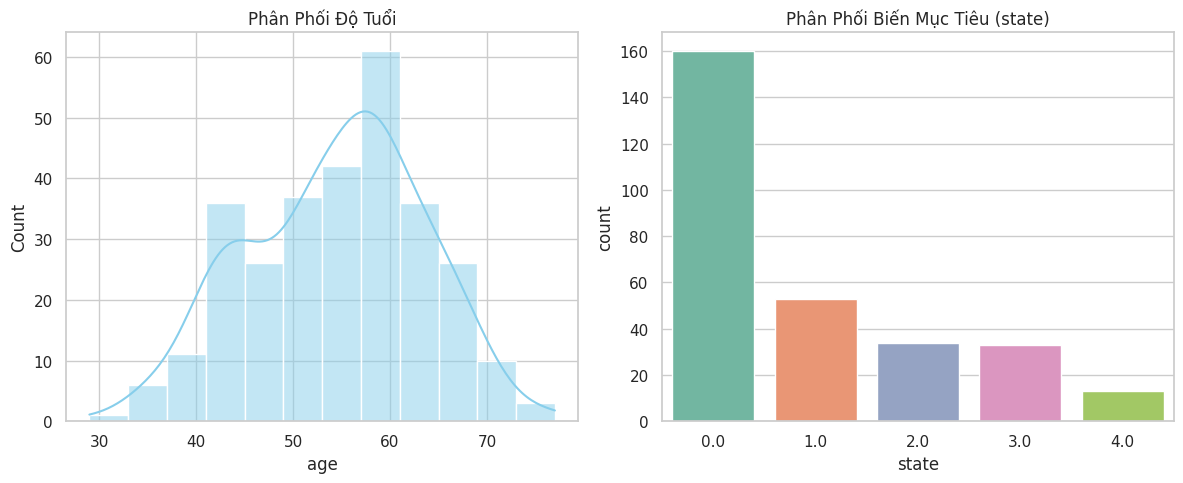

In [4]:
# Thiết lập giao diện cho đồ thị
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))

# Biểu đồ 1: Phân phối độ tuổi (Age)
plt.subplot(1, 2, 1)
sns.histplot(data=df, x=df.columns[0], kde=True, color="skyblue") # Giả định cột đầu tiên thường là Age hoặc dùng df['age'] nếu đúng tên
plt.title("Phân Phối Độ Tuổi")

# Biểu đồ 2: Đếm số lượng biến mục tiêu (Target - Mắc bệnh hay không)
# Thay 'target' bằng tên cột kết quả trong file của bạn (ví dụ: 'target', 'num', 'heart_disease')
target_col = df.columns[-1] # Giả định cột cuối cùng là biến mục tiêu
plt.subplot(1, 2, 2)
sns.countplot(data=df, x=target_col, palette="Set2")
plt.title(f"Phân Phối Biến Mục Tiêu ({target_col})")

plt.tight_layout()
plt.show()